# Primer Parcial — Clasificación de comandos de voz

Estudiante: Chungara Choque Elizabeth. Dataset: Google Speech Commands v0.02. El modelo MLP en PyTorch clasifica audios de diez palabras en inglés: yes, no, up, down, left, right, on, off, stop y go. Se utiliza una muestra de m = 7000 audios: 5000 de entrenamiento, 1000 de validación y 1000 de prueba. Cada audio se representa mediante n = 640 características MFCC; X contiene esas características e y identifica la palabra con una etiqueta de 0 a 9.

Fuente: https://huggingface.co/datasets/google/speech_commands


In [1]:
import os
import random
import time
import wave
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

semilla = 42
random.seed(semilla)
np.random.seed(semilla)
torch.manual_seed(semilla)

print("PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())
print("Semilla:", semilla)


PyTorch: 2.14.0+cu130
GPU disponible: True
Semilla: 42


In [2]:
ruta_actual = os.getcwd()
ruta_dataset = os.path.join(ruta_actual, "DataSet")
ruta_resultados = os.path.join(ruta_actual, "resultados_audio_examen")

if not os.path.isdir(ruta_dataset):
    raise FileNotFoundError("No existe DataSet. Ajusta ruta_dataset a la carpeta descomprimida.")

os.makedirs(ruta_resultados, exist_ok=True)
print("Dataset:", ruta_dataset)
print("Resultados:", ruta_resultados)


Dataset: c:\Users\HP\Desktop\UNI\7moo SEMESTRE\SIS420 INTELIGENCIA ARTIFICIAL\SIS420 INTELIGENCIA ARTIFICIAL\EXAMEN_AUDIO\DataSet
Resultados: c:\Users\HP\Desktop\UNI\7moo SEMESTRE\SIS420 INTELIGENCIA ARTIFICIAL\SIS420 INTELIGENCIA ARTIFICIAL\EXAMEN_AUDIO\resultados_audio_examen


In [3]:
clases = [
    "yes", "no", "up", "down", "left",
    "right", "on", "off", "stop", "go"
]

conteos = []

for clase in clases:
    carpeta = os.path.join(ruta_dataset, clase)
    archivos = [
        nombre for nombre in os.listdir(carpeta)
        if nombre.lower().endswith(".wav")
        and os.path.isfile(os.path.join(carpeta, nombre))
    ]
    conteos.append(len(archivos))

tabla_clases = pd.DataFrame({
    "Clase": clases,
    "Cantidad de audios": conteos
})

print(tabla_clases.to_string(index=False))
print("\nTotal de audios seleccionados:", sum(conteos))
print("Número de clases:", len(clases))

for nombre in ["validation_list.txt", "testing_list.txt"]:
    print(nombre, "encontrado:", os.path.isfile(
        os.path.join(ruta_dataset, nombre)
    ))


Clase  Cantidad de audios
  yes                4044
   no                3941
   up                3723
 down                3917
 left                3801
right                3778
   on                3845
  off                3745
 stop                3872
   go                3880

Total de audios seleccionados: 38546
Número de clases: 10
validation_list.txt encontrado: True
testing_list.txt encontrado: True


In [4]:
with open(os.path.join(ruta_dataset, "validation_list.txt")) as archivo:
    lista_val = {linea.strip().replace("\\", "/") for linea in archivo if linea.strip()}

with open(os.path.join(ruta_dataset, "testing_list.txt")) as archivo:
    lista_test = {linea.strip().replace("\\", "/") for linea in archivo if linea.strip()}

registros = []

for etiqueta, clase in enumerate(clases):
    carpeta = os.path.join(ruta_dataset, clase)

    for nombre in sorted(os.listdir(carpeta)):
        ruta = os.path.join(carpeta, nombre)

        if not nombre.lower().endswith(".wav") or not os.path.isfile(ruta):
            continue

        relativa = clase + "/" + nombre

        if relativa in lista_val:
            particion = "validacion"
        elif relativa in lista_test:
            particion = "prueba"
        else:
            particion = "entrenamiento"

        registros.append({
            "ruta": ruta,
            "clase": clase,
            "etiqueta": etiqueta,
            "hablante": nombre.split("_nohash_")[0],
            "particion": particion
        })

datos = pd.DataFrame(registros)

resumen = pd.crosstab(datos["clase"], datos["particion"])
resumen = resumen.reindex(
    index=clases,
    columns=["entrenamiento", "validacion", "prueba"],
    fill_value=0
)

assert len(datos) == sum(conteos)
assert (resumen > 0).all().all()

hablantes_train = set(datos.loc[
    datos["particion"] == "entrenamiento", "hablante"
])
hablantes_val = set(datos.loc[
    datos["particion"] == "validacion", "hablante"
])
hablantes_test = set(datos.loc[
    datos["particion"] == "prueba", "hablante"
])

assert hablantes_train.isdisjoint(hablantes_val)
assert hablantes_train.isdisjoint(hablantes_test)
assert hablantes_val.isdisjoint(hablantes_test)

print(resumen.to_string())
print("\nTotales por partición:")
print(resumen.sum().to_string())
print("\nComprobación correcta: no se comparten hablantes entre particiones.")


particion  entrenamiento  validacion  prueba
clase                                       
yes                 3228         397     419
no                  3130         406     405
up                  2948         350     425
down                3134         377     406
left                3037         352     412
right               3019         363     396
on                  3086         363     396
off                 2970         373     402
stop                3111         350     411
go                  3106         372     402

Totales por partición:
particion
entrenamiento    30769
validacion        3703
prueba            4074

Comprobación correcta: no se comparten hablantes entre particiones.


In [5]:
particiones = {
    "entrenamiento": 500,
    "validacion": 100,
    "prueba": 100
}

muestras = []

for clase in clases:
    for particion, cantidad in particiones.items():
        grupo = datos.loc[
            (datos["clase"] == clase) &
            (datos["particion"] == particion)
        ]
        muestras.append(grupo.sample(n=cantidad, random_state=semilla))

datos_muestra = pd.concat(muestras, ignore_index=True)

print(pd.crosstab(
    datos_muestra["clase"],
    datos_muestra["particion"]
).to_string())
print("\nTotal de audios de la muestra:", len(datos_muestra))
assert not datos_muestra["ruta"].duplicated().any()
datos_muestra.to_csv(os.path.join(ruta_resultados, "muestra_utilizada.csv"), index=False)


particion  entrenamiento  prueba  validacion
clase                                       
down                 500     100         100
go                   500     100         100
left                 500     100         100
no                   500     100         100
off                  500     100         100
on                   500     100         100
right                500     100         100
stop                 500     100         100
up                   500     100         100
yes                  500     100         100

Total de audios de la muestra: 7000


In [6]:
frecuencias_fft = np.fft.rfftfreq(1024, d=1 / 16000)

def a_mel(hz):
    return 2595 * np.log10(1 + hz / 700)

def a_hz(mel):
    return 700 * (10 ** (mel / 2595) - 1)

puntos_mel = np.linspace(a_mel(0), a_mel(8000), 42)
puntos_hz = a_hz(puntos_mel)
filtros_mel = np.zeros((40, len(frecuencias_fft)), dtype=np.float32)

for i in range(40):
    subida = (frecuencias_fft - puntos_hz[i]) / (puntos_hz[i + 1] - puntos_hz[i])
    bajada = (puntos_hz[i + 2] - frecuencias_fft) / (puntos_hz[i + 2] - puntos_hz[i + 1])
    filtros_mel[i] = np.maximum(0, np.minimum(subida, bajada))

ventana = np.hanning(1024).astype(np.float32)
indices = np.arange(40)
base_dct = np.cos(np.pi / 40 * (indices + 0.5)[None, :] * np.arange(20)[:, None])
base_dct = base_dct.astype(np.float32)
base_dct[0] *= np.sqrt(1 / 40)
base_dct[1:] *= np.sqrt(2 / 40)

def extraer_mfcc(ruta):
    with wave.open(ruta, "rb") as archivo:
        assert archivo.getframerate() == 16000
        assert archivo.getnchannels() == 1
        assert archivo.getsampwidth() == 2
        audio = np.frombuffer(archivo.readframes(16000), dtype="<i2").astype(np.float32) / 32768

    audio = np.pad(audio[:16000], (0, max(0, 16000 - len(audio))))
    audio = np.pad(audio, (512, 512))

    ventanas = np.stack([
        audio[inicio:inicio + 1024] * ventana
        for inicio in range(0, len(audio) - 1024 + 1, 512)
    ])

    potencia = np.abs(np.fft.rfft(ventanas, axis=1)) ** 2
    energia_mel = np.einsum("tf,mf->mt", potencia, filtros_mel, optimize=False)
    mfcc = np.einsum(
        "km,mt->kt",
        base_dct,
        np.log(energia_mel + 1e-10),
        optimize=False
    )

    return mfcc.astype(np.float32).reshape(-1)

ejemplo = datos_muestra.iloc[0]
caracteristicas_ejemplo = extraer_mfcc(ejemplo["ruta"])

print("Clase:", ejemplo["clase"])
print("Cantidad de características:", caracteristicas_ejemplo.shape)
print("Valores finitos:", np.isfinite(caracteristicas_ejemplo).all())


Clase: yes
Cantidad de características: (640,)
Valores finitos: True


In [7]:
carpeta_cache = os.path.join(ruta_actual, "cache_mfcc")
os.makedirs(carpeta_cache, exist_ok=True)
version_mfcc = "numpy_hann1024_hop512_mel40_mfcc20_v1"
X_conjuntos = {}
y_conjuntos = {}

for particion in ["entrenamiento", "validacion", "prueba"]:
    partes_X = []
    partes_y = []
    for clase in clases:
        filas = datos_muestra.loc[
            (datos_muestra["particion"] == particion) &
            (datos_muestra["clase"] == clase)
        ]
        rutas = filas["ruta"].to_numpy(dtype=str)
        archivo_cache = os.path.join(carpeta_cache, f"{particion}_{clase}.npz")
        inicio = time.perf_counter()
        X_clase = None
        if os.path.exists(archivo_cache):
            try:
                with np.load(archivo_cache, allow_pickle=False) as guardado:
                    if "version" in guardado.files:
                        if guardado["version"].item() == version_mfcc and np.array_equal(guardado["rutas"], rutas):
                            candidato = guardado["X"]
                            if candidato.shape == (len(rutas), 640) and np.isfinite(candidato).all():
                                X_clase = candidato
            except (OSError, ValueError, KeyError):
                X_clase = None
        if X_clase is None:
            X_clase = np.stack([extraer_mfcc(ruta) for ruta in rutas])
            assert X_clase.shape == (len(rutas), 640)
            assert np.isfinite(X_clase).all()
            np.savez_compressed(archivo_cache, X=X_clase, rutas=rutas, version=version_mfcc)
            estado = "Calculado"
        else:
            estado = "Recuperado"
        partes_X.append(X_clase)
        partes_y.append(filas["etiqueta"].to_numpy())
        print(f"{estado}: {particion}, {clase}, {len(rutas)} audios, {time.perf_counter() - inicio:.1f} s", flush=True)
    X_conjuntos[particion] = np.concatenate(partes_X).astype(np.float32)
    y_conjuntos[particion] = np.concatenate(partes_y).astype(np.int64)
    print(particion, X_conjuntos[particion].shape)

X_train_raw, y_train = X_conjuntos["entrenamiento"], y_conjuntos["entrenamiento"]
X_val_raw, y_val = X_conjuntos["validacion"], y_conjuntos["validacion"]
X_test_raw, y_test = X_conjuntos["prueba"], y_conjuntos["prueba"]


Recuperado: entrenamiento, yes, 500 audios, 0.0 s
Recuperado: entrenamiento, no, 500 audios, 0.0 s
Recuperado: entrenamiento, up, 500 audios, 0.0 s
Recuperado: entrenamiento, down, 500 audios, 0.0 s
Recuperado: entrenamiento, left, 500 audios, 0.0 s
Recuperado: entrenamiento, right, 500 audios, 0.0 s
Recuperado: entrenamiento, on, 500 audios, 0.0 s
Recuperado: entrenamiento, off, 500 audios, 0.0 s
Recuperado: entrenamiento, stop, 500 audios, 0.0 s
Recuperado: entrenamiento, go, 500 audios, 0.0 s
entrenamiento (5000, 640)
Recuperado: validacion, yes, 100 audios, 0.0 s
Recuperado: validacion, no, 100 audios, 0.0 s
Recuperado: validacion, up, 100 audios, 0.0 s
Recuperado: validacion, down, 100 audios, 0.0 s
Recuperado: validacion, left, 100 audios, 0.0 s
Recuperado: validacion, right, 100 audios, 0.0 s
Recuperado: validacion, on, 100 audios, 0.0 s
Recuperado: validacion, off, 100 audios, 0.0 s
Recuperado: validacion, stop, 100 audios, 0.0 s
Recuperado: validacion, go, 100 audios, 0.0 s
va

In [8]:
media_train = X_train_raw.mean(axis=0)
desviacion_train = X_train_raw.std(axis=0)
desviacion_train[desviacion_train < 1e-8] = 1.0

X_train = ((X_train_raw - media_train) / desviacion_train).astype(np.float32)
X_val = ((X_val_raw - media_train) / desviacion_train).astype(np.float32)
X_test = ((X_test_raw - media_train) / desviacion_train).astype(np.float32)

for nombre, X in [("Entrenamiento", X_train), ("Validación", X_val), ("Prueba", X_test)]:
    assert np.isfinite(X).all()
    print(nombre, X.shape, "valores finitos:", np.isfinite(X).all())


Entrenamiento (5000, 640) valores finitos: True
Validación (1000, 640) valores finitos: True
Prueba (1000, 640) valores finitos: True


In [9]:
class DatasetPersonalizado(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, indice):
        return self.X[indice], self.y[indice]

dataset_train = DatasetPersonalizado(X_train, y_train)
dataset_val = DatasetPersonalizado(X_val, y_val)
dataset_test = DatasetPersonalizado(X_test, y_test)

loader_train = DataLoader(dataset_train, batch_size=100, shuffle=True, num_workers=0)
loader_val = DataLoader(dataset_val, batch_size=100, shuffle=False, num_workers=0)
loader_test = DataLoader(dataset_test, batch_size=100, shuffle=False, num_workers=0)

X_lote, y_lote = next(iter(loader_train))

print("Audios:", len(dataset_train), len(dataset_val), len(dataset_test))
print("Forma de un lote:", X_lote.shape)
print("Forma de sus etiquetas:", y_lote.shape)


Audios: 5000 1000 1000
Forma de un lote: torch.Size([100, 640])
Forma de sus etiquetas: torch.Size([100])


In [10]:
torch.manual_seed(semilla)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Sequential(
    nn.Linear(640, 100),
    nn.ReLU(),
    nn.Linear(100, 10)
).to(device)

with torch.no_grad():
    salida_ejemplo = model(X_lote[:2].to(device))

print("Dispositivo:", device)
print(model)
print("Forma de la salida para 2 audios:", salida_ejemplo.shape)


Dispositivo: cuda
Sequential(
  (0): Linear(in_features=640, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=10, bias=True)
)
Forma de la salida para 2 audios: torch.Size([2, 10])


In [11]:
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

perdida_inicial = criterion(salida_ejemplo, y_lote[:2].to(device))

print("Función de pérdida:", criterion)
print("Optimizador:", type(optimizer).__name__)
print("Tasa de aprendizaje:", learning_rate)
print("Pérdida inicial de 2 audios:", perdida_inicial.item())

Función de pérdida: CrossEntropyLoss()
Optimizador: Adam
Tasa de aprendizaje: 0.001
Pérdida inicial de 2 audios: 2.4905178546905518


In [12]:
max_epochs = 30
patience = 3

historial_train = []
historial_val = []
historial_acc_train = []
historial_acc_val = []

mejor_val_loss = float("inf")
mejor_estado = None
mejor_epoca = 0
epocas_sin_mejora = 0

for epoch in range(1, max_epochs + 1):
    model.train()
    suma_loss_train = 0.0
    aciertos_train = 0

    for X_batch, y_batch in loader_train:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        salidas = model(X_batch)
        loss = criterion(salidas, y_batch)
        loss.backward()
        optimizer.step()

        suma_loss_train += loss.item() * len(y_batch)
        aciertos_train += (torch.argmax(salidas, dim=1) == y_batch).sum().item()

    train_loss = suma_loss_train / len(dataset_train)
    train_acc = aciertos_train / len(dataset_train)

    model.eval()
    suma_loss_val = 0.0
    aciertos_val = 0

    with torch.no_grad():
        for X_batch, y_batch in loader_val:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            salidas = model(X_batch)
            loss = criterion(salidas, y_batch)

            suma_loss_val += loss.item() * len(y_batch)
            aciertos_val += (torch.argmax(salidas, dim=1) == y_batch).sum().item()

    val_loss = suma_loss_val / len(dataset_val)
    val_acc = aciertos_val / len(dataset_val)

    historial_train.append(train_loss)
    historial_val.append(val_loss)
    historial_acc_train.append(train_acc)
    historial_acc_val.append(val_acc)

    print(
        f"Época {epoch:02d} | "
        f"train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | "
        f"train acc: {train_acc:.3f} | val acc: {val_acc:.3f}",
        flush=True
    )

    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        mejor_estado = deepcopy(model.state_dict())
        mejor_epoca = epoch
        epocas_sin_mejora = 0
        torch.save(mejor_estado, os.path.join(ruta_resultados, "mejor_modelo_audio.pth"))
    else:
        epocas_sin_mejora += 1
        if epocas_sin_mejora >= patience:
            print("Detención temprana: tres épocas sin mejorar la pérdida de validación.")
            break

model.load_state_dict(mejor_estado)
print(f"Mejor época: {mejor_epoca} | pérdida de validación: {mejor_val_loss:.4f}")


Época 01 | train loss: 1.8706 | val loss: 1.5216 | train acc: 0.381 | val acc: 0.509
Época 02 | train loss: 1.2551 | val loss: 1.2956 | train acc: 0.613 | val acc: 0.575
Época 03 | train loss: 0.9742 | val loss: 1.2065 | train acc: 0.699 | val acc: 0.604
Época 04 | train loss: 0.7811 | val loss: 1.1537 | train acc: 0.764 | val acc: 0.625
Época 05 | train loss: 0.6345 | val loss: 1.1122 | train acc: 0.818 | val acc: 0.646
Época 06 | train loss: 0.5174 | val loss: 1.0940 | train acc: 0.862 | val acc: 0.646
Época 07 | train loss: 0.4193 | val loss: 1.0913 | train acc: 0.902 | val acc: 0.666
Época 08 | train loss: 0.3430 | val loss: 1.1065 | train acc: 0.927 | val acc: 0.652
Época 09 | train loss: 0.2788 | val loss: 1.1076 | train acc: 0.948 | val acc: 0.663
Época 10 | train loss: 0.2268 | val loss: 1.1174 | train acc: 0.961 | val acc: 0.678
Detención temprana: tres épocas sin mejorar la pérdida de validación.
Mejor época: 7 | pérdida de validación: 1.0913


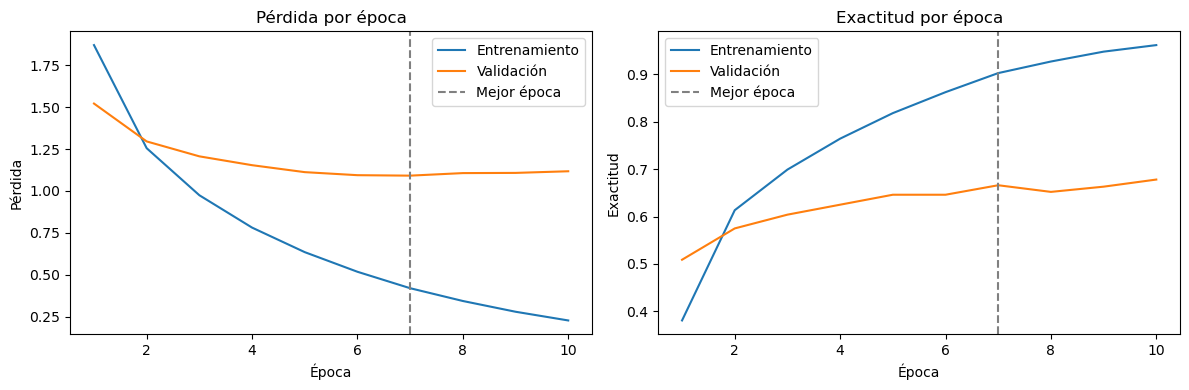

In [13]:
epocas = range(1, len(historial_train) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epocas, historial_train, label="Entrenamiento")
plt.plot(epocas, historial_val, label="Validación")
plt.axvline(mejor_epoca, color="gray", linestyle="--", label="Mejor época")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida por época")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epocas, historial_acc_train, label="Entrenamiento")
plt.plot(epocas, historial_acc_val, label="Validación")
plt.axvline(mejor_epoca, color="gray", linestyle="--", label="Mejor época")
plt.xlabel("Época")
plt.ylabel("Exactitud")
plt.title("Exactitud por época")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#METRICAS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model.eval()
etiquetas_reales = []
etiquetas_predichas = []
probabilidades_test = []
suma_loss_test = 0.0

with torch.no_grad():
    for X_batch, y_batch in loader_test:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        salidas = model(X_batch)
        loss = criterion(salidas, y_batch)
        predicciones = torch.argmax(salidas, dim=1)
        suma_loss_test += loss.item() * len(y_batch)
        etiquetas_reales.extend(y_batch.cpu().numpy())
        etiquetas_predichas.extend(predicciones.cpu().numpy())
        probabilidades_test.append(torch.softmax(salidas, dim=1).cpu().numpy())

etiquetas_reales = np.asarray(etiquetas_reales)
etiquetas_predichas = np.asarray(etiquetas_predichas)
probabilidades_test = np.concatenate(probabilidades_test)
assert np.array_equal(etiquetas_reales, y_test)
assert np.isfinite(probabilidades_test).all()
assert np.allclose(probabilidades_test.sum(axis=1), 1, atol=1e-5)

clase_base = int(np.argmax(np.bincount(y_train, minlength=len(clases))))
predicciones_base = np.full(len(y_test), clase_base)
baseline_acc = accuracy_score(y_test, predicciones_base)
test_loss = suma_loss_test / len(dataset_test)
test_acc = accuracy_score(etiquetas_reales, etiquetas_predichas)
test_f1 = f1_score(etiquetas_reales, etiquetas_predichas, average="macro", zero_division=0)

metricas = pd.DataFrame({
    "Métrica": ["Exactitud baseline", "Exactitud MLP", "Precisión macro", "Recall macro", "F1 macro"],
    "Valor": [baseline_acc, test_acc,
              precision_score(etiquetas_reales, etiquetas_predichas, average="macro", zero_division=0),
              recall_score(etiquetas_reales, etiquetas_predichas, average="macro", zero_division=0), test_f1]
})
print(f"Pérdida en prueba: {test_loss:.4f}")
print(f"Baseline: predecir siempre {clases[clase_base]}")
print(metricas.to_string(index=False))
print(classification_report(etiquetas_reales, etiquetas_predichas,
                            labels=range(len(clases)), target_names=clases,
                            digits=3, zero_division=0))
metricas.to_csv(os.path.join(ruta_resultados, "metricas.csv"), index=False)


Pérdida en prueba: 1.0396
Baseline: predecir siempre yes
           Métrica    Valor
Exactitud baseline 0.100000
     Exactitud MLP 0.661000
   Precisión macro 0.666079
      Recall macro 0.661000
          F1 macro 0.662161
              precision    recall  f1-score   support

         yes      0.765     0.780     0.772       100
          no      0.509     0.540     0.524       100
          up      0.587     0.640     0.612       100
        down      0.545     0.540     0.543       100
        left      0.644     0.670     0.657       100
       right      0.734     0.800     0.766       100
          on      0.771     0.640     0.699       100
         off      0.730     0.650     0.688       100
        stop      0.804     0.740     0.771       100
          go      0.570     0.610     0.589       100

    accuracy                          0.661      1000
   macro avg      0.666     0.661     0.662      1000
weighted avg      0.666     0.661     0.662      1000



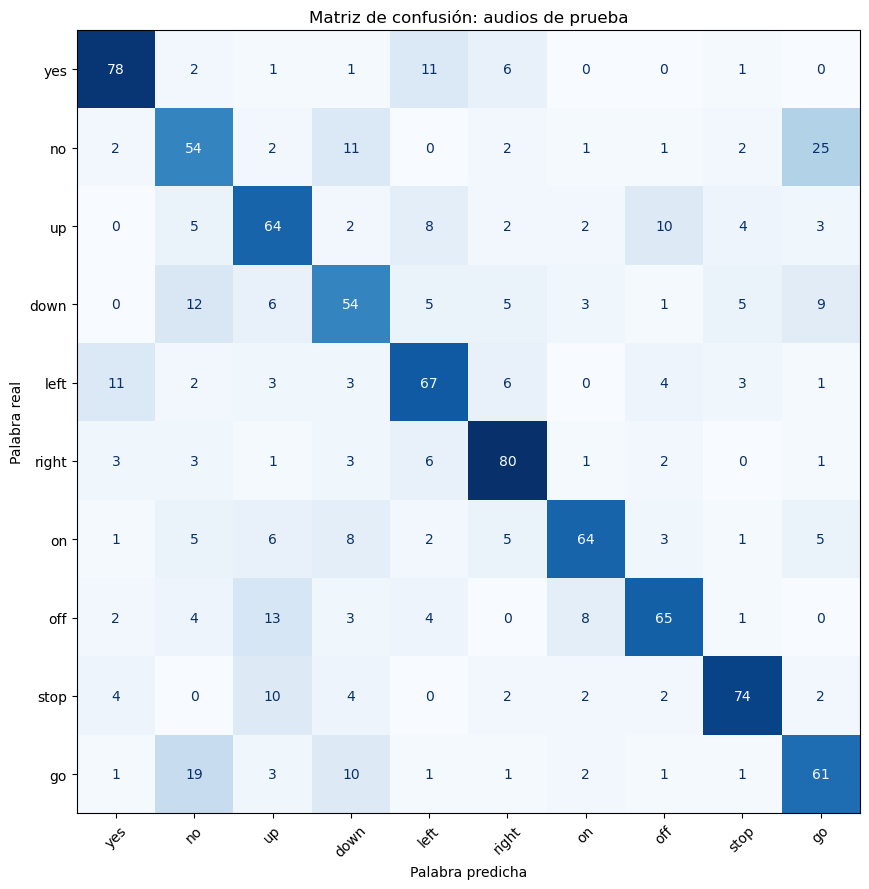

In [ ]:
#MATRIZ DE CONFUSION
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matriz = confusion_matrix(
    etiquetas_reales,
    etiquetas_predichas,
    labels=range(len(clases))
)

fig, ax = plt.subplots(figsize=(10, 9))

visualizacion = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=clases
)

visualizacion.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("Matriz de confusión: audios de prueba")
ax.set_xlabel("Palabra predicha")
ax.set_ylabel("Palabra real")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

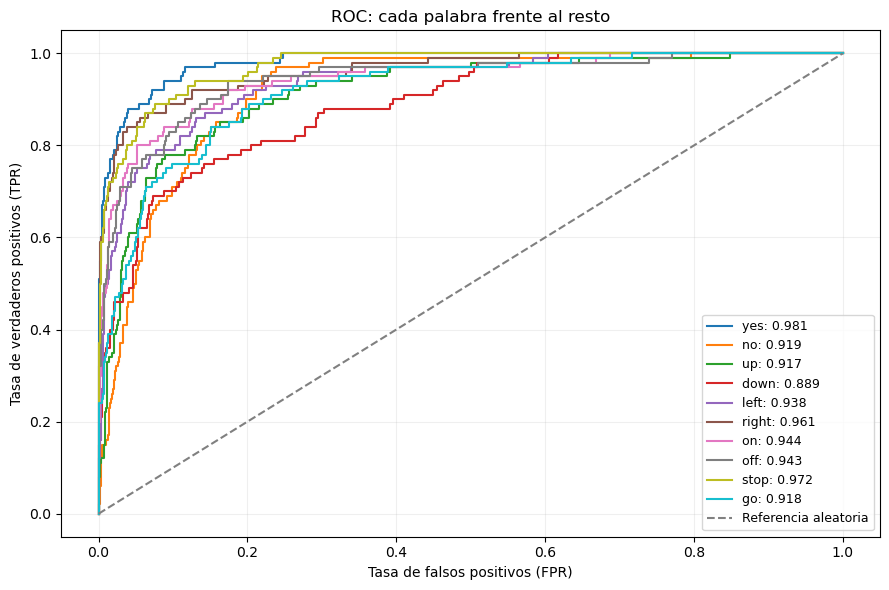

Clase      AUC
  yes 0.980833
   no 0.919022
   up 0.916522
 down 0.889322
 left 0.937667
right 0.961456
   on 0.943811
  off 0.943289
 stop 0.971822
   go 0.917933
AUC macro one-vs-rest: 0.9382


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(9, 6))
resultados_auc = []

for etiqueta, clase in enumerate(clases):
    positivos = (etiquetas_reales == etiqueta).astype(int)
    puntuaciones = probabilidades_test[:, etiqueta]
    fpr, tpr, umbrales = roc_curve(positivos, puntuaciones)
    auc_clase = roc_auc_score(positivos, puntuaciones)
    resultados_auc.append({"Clase": clase, "AUC": auc_clase})
    ax.plot(fpr, tpr, label=f"{clase}: {auc_clase:.3f}")

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Referencia aleatoria")
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_title("ROC: cada palabra frente al resto")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

tabla_auc = pd.DataFrame(resultados_auc)
auc_macro = tabla_auc["AUC"].mean()
print(tabla_auc.to_string(index=False))
print(f"AUC macro one-vs-rest: {auc_macro:.4f}")
tabla_auc.to_csv(os.path.join(ruta_resultados, "auc_por_clase.csv"), index=False)


In [17]:
ruta_modelo = os.path.join(ruta_resultados, "modelo_audio_completo.pth")
paquete = {
    "estado_modelo": {nombre: valor.detach().cpu() for nombre, valor in model.state_dict().items()},
    "media": torch.from_numpy(media_train.copy()),
    "desviacion": torch.from_numpy(desviacion_train.copy()),
    "clases": list(clases),
    "arquitectura": [640, 100, 10],
    "version_mfcc": version_mfcc,
    "frecuencia": 16000,
    "muestras": 16000,
    "n_fft": 1024,
    "hop_length": 512,
    "n_mels": 40,
    "n_mfcc": 20,
    "mejor_epoca": mejor_epoca,
    "criterio_seleccion": "minima perdida de validacion",
    "semilla": semilla
}
torch.save(paquete, ruta_modelo)

recuperado = torch.load(ruta_modelo, map_location="cpu", weights_only=True)
entradas, ocultas, salidas = recuperado["arquitectura"]
modelo_recuperado = nn.Sequential(
    nn.Linear(entradas, ocultas),
    nn.ReLU(),
    nn.Linear(ocultas, salidas)
).to(device)
modelo_recuperado.load_state_dict(recuperado["estado_modelo"])
modelo_recuperado.eval()
model.eval()

X_comprobacion = dataset_val.X[:10].to(device)
with torch.no_grad():
    salida_original = model(X_comprobacion)
    salida_recuperada = modelo_recuperado(X_comprobacion)

assert torch.allclose(salida_original, salida_recuperada, atol=1e-6)
print("Modelo guardado:", ruta_modelo)
print("Carga comprobada: las salidas coinciden.")


Modelo guardado: c:\Users\HP\Desktop\UNI\7moo SEMESTRE\SIS420 INTELIGENCIA ARTIFICIAL\SIS420 INTELIGENCIA ARTIFICIAL\EXAMEN_AUDIO\resultados_audio_examen\modelo_audio_completo.pth
Carga comprobada: las salidas coinciden.


In [18]:
ejemplo_prueba = datos_muestra.loc[datos_muestra["particion"] == "prueba"].iloc[0]
assert recuperado["version_mfcc"] == version_mfcc

vector = extraer_mfcc(ejemplo_prueba["ruta"])
media_guardada = recuperado["media"].numpy()
desviacion_guardada = recuperado["desviacion"].numpy()
vector = ((vector - media_guardada) / desviacion_guardada).astype(np.float32)
entrada = torch.from_numpy(vector).unsqueeze(0).to(device)

with torch.no_grad():
    logits = modelo_recuperado(entrada)
    probabilidades = torch.softmax(logits, dim=1)
    etiqueta_predicha = torch.argmax(logits, dim=1).item()

print("Archivo:", os.path.basename(ejemplo_prueba["ruta"]))
print("Palabra real:", ejemplo_prueba["clase"])
print("Palabra predicha:", recuperado["clases"][etiqueta_predicha])
print(f"Probabilidad de la clase predicha: {probabilidades[0, etiqueta_predicha].item():.3f}")

from IPython.display import Audio, display

display(Audio(filename=ejemplo_prueba["ruta"]))


Archivo: 94de6a6a_nohash_4.wav
Palabra real: yes
Palabra predicha: yes
Probabilidad de la clase predicha: 0.689


In [19]:
aciertos = int(np.trace(matriz))
errores = int(matriz.sum() - aciertos)
confusiones = matriz.copy()
np.fill_diagonal(confusiones, 0)
real, predicha = np.unravel_index(np.argmax(confusiones), confusiones.shape)

print(f"Muestra total: {len(datos_muestra)} audios; {len(clases)} clases; {X_train.shape[1]} características.")
print(f"Mejor época por pérdida de validación: {mejor_epoca}.")
print(f"Pérdida de validación seleccionada: {mejor_val_loss:.4f}.")
print(f"Exactitud de validación en esa época: {historial_acc_val[mejor_epoca - 1]:.1%}.")
print(f"Prueba: {aciertos} aciertos y {errores} errores; exactitud {test_acc:.1%}.")
print(f"Baseline: {baseline_acc:.1%}; diferencia {(test_acc - baseline_acc) * 100:.1f} puntos porcentuales.")
print(f"F1 macro: {test_f1:.3f}; AUC macro: {auc_macro:.3f}.")
if errores:
    print(f"Mayor confusión: {clases[real]} → {clases[predicha]}, {confusiones[real, predicha]} audios.")

pd.DataFrame({
    "epoca": list(range(1, len(historial_train) + 1)),
    "train_loss": historial_train,
    "val_loss": historial_val,
    "train_acc": historial_acc_train,
    "val_acc": historial_acc_val
}).to_csv(os.path.join(ruta_resultados, "historial.csv"), index=False)


Muestra total: 7000 audios; 10 clases; 640 características.
Mejor época por pérdida de validación: 7.
Pérdida de validación seleccionada: 1.0913.
Exactitud de validación en esa época: 66.6%.
Prueba: 661 aciertos y 339 errores; exactitud 66.1%.
Baseline: 10.0%; diferencia 56.1 puntos porcentuales.
F1 macro: 0.662; AUC macro: 0.938.
Mayor confusión: no → go, 25 audios.
